# Predict Parent Motivation — Universal Structured Classifiers

Can we predict *why* a parent flagged a highlight (`parent_motivation`) from features
that are knowable **before** any parent rating — strategy, scenario, and demographics?

**Target**: `parent_motivation` — 8 nominal classes (262 usable rows after dropping 5 null).
**Features**: strategy + scenario + demographics (~71 a-priori features; no `motiv_*`).

**Models**: Majority Baseline, Stratified Baseline, Logistic Regression, Decision Tree,
Random Forest, LightGBM.

**Primary metric**: weighted F1 (handles 8-class imbalance).
**Secondary**: macro F1, top-2 accuracy.
**Majority baseline**: predict Response Usefulness (96/262 ≈ 36.6 %).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold, KFold, cross_validate, train_test_split,
)
from sklearn.metrics import (
    f1_score, make_scorer, ConfusionMatrixDisplay,
)
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb

DATA_DIR   = Path('../../data-exports/20260412_183830')
OUTPUT_DIR = DATA_DIR / 'highlight_analysis_output'
OUT_DIR    = OUTPUT_DIR / 'motivation_classifier_output'
OUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
OUTER_K      = 5

## Load data

Merge R5 motivation codes onto df_sel so we use the authoritative round-5 labels.

In [2]:
df_sel = pd.read_csv(OUTPUT_DIR / 'df_sel.csv')

r5 = pd.read_csv(DATA_DIR / 'R5_highlights_coded', sep='\t')
r5.columns = r5.columns.str.strip()
r5 = r5.rename(columns={
    'highlight_id':    'selection_id',
    'Parent Motivation': 'r5_motivation',
    'Model Strategy':    'r5_strategy',
})
r5['r5_motivation'] = r5['r5_motivation'].replace({
    '': None, 'null': None,
    'Response Could Evoke Strong Emotion': 'Response Could Evoke Strong Emotions',
    'Parents Trust of Model Capabilities': None,
})
r5 = r5[r5['r5_motivation'].notna()]

df = df_sel.merge(r5[['selection_id', 'r5_motivation']], on='selection_id', how='inner')
df = df.drop(columns=['parent_motivation'], errors='ignore').rename(
    columns={'r5_motivation': 'parent_motivation'}
)
df = df.reset_index(drop=True)

print(f'Shape after R5 merge: {df.shape}')
print(f'Unique parents: {df["prolific_pid"].nunique()}')
print(f'Motivation nulls remaining: {df["parent_motivation"].isna().sum()}')
print(f'\nMotivation class counts:')
print(df['parent_motivation'].value_counts().to_string())

Shape after R5 merge: (467, 48)
Unique parents: 20
Motivation nulls remaining: 0

Motivation class counts:
parent_motivation
Response Usefulness                          196
Response Could Evoke Strong Emotions          89
Response Risk Awareness                       70
Response Identification of the Root Cause     41
Response Organization                         24
Child Intentions                              22
Response Complexity                           19
Response Confirmation / Contradiction          6


In [3]:
le = LabelEncoder()
y  = le.fit_transform(df['parent_motivation'])
CLASSES = le.classes_
N_CLASSES = len(CLASSES)
print(f'{N_CLASSES} classes, {len(y)} rows')
for i, (cls, n) in enumerate(zip(CLASSES, np.bincount(y))):
    print(f'  [{i}] {cls}: {n}')

majority_class = CLASSES[np.bincount(y).argmax()]
majority_pct   = np.bincount(y).max() / len(y)
print(f'\nMajority baseline class: {majority_class!r} ({majority_pct:.1%})')

8 classes, 467 rows
  [0] Child Intentions: 22
  [1] Response Complexity: 19
  [2] Response Confirmation / Contradiction: 6
  [3] Response Could Evoke Strong Emotions: 89
  [4] Response Identification of the Root Cause: 41
  [5] Response Organization: 24
  [6] Response Risk Awareness: 70
  [7] Response Usefulness: 196

Majority baseline class: 'Response Usefulness' (42.0%)


## Target distribution

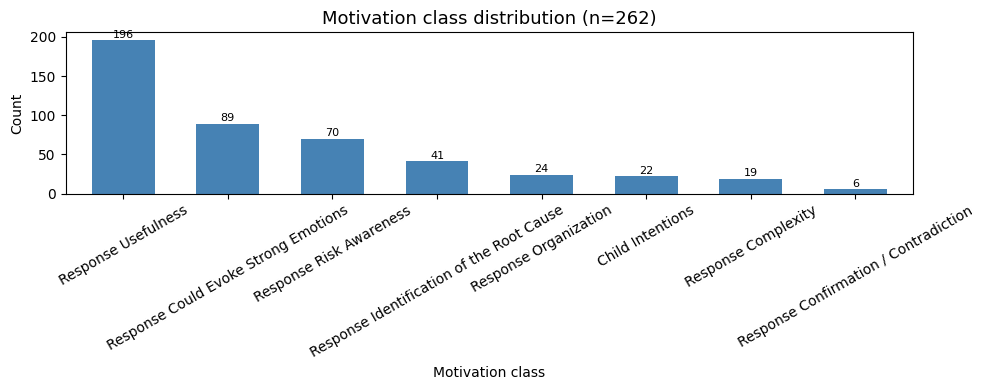

In [4]:
vc = pd.Series(np.bincount(y), index=CLASSES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
vc.plot.bar(ax=ax, color='steelblue', width=0.6)
ax.set_title('Motivation class distribution (n=262)', fontsize=13)
ax.set_xlabel('Motivation class')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 0.5, int(p.get_height()),
            ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'motivation_class_distribution.png', dpi=100)
plt.show()

## Feature engineering (a priori — no motivation columns)

In [5]:
def build_features(df_in: pd.DataFrame) -> pd.DataFrame:
    """A-priori feature set: strategy + scenario + demographics.  No motiv_* columns."""
    out = pd.DataFrame(index=df_in.index)
    # Strategy
    out['strategy_is_null'] = df_in['model_strategy'].isna().astype(int)
    out = pd.concat([out,
        pd.get_dummies(df_in['model_strategy'].fillna('none'), prefix='strat'),
    ], axis=1)
    # Scenario / prompt factors
    for col in ['domain', 'age_band', 'sensitivity_level', 'relationship_frame',
                'space_type', 'trait', 'trait_level']:
        out = pd.concat([out,
            pd.get_dummies(df_in[col].fillna('unknown'), prefix=col)
        ], axis=1)
    out['breakdown_expected'] = (df_in['breakdown_expected'] == 'yes').astype(int)
    if 'source' in df_in.columns:
        out = pd.concat([out,
            pd.get_dummies(df_in['source'].fillna('unknown'), prefix='source')
        ], axis=1)
    # Parent demographics
    for col in ['parent_gender', 'parent_age_group', 'parent_education', 'parent_ethnicity',
                'area_of_residency', 'child_has_ai_use', 'parent_llm_monitoring_level']:
        out = pd.concat([out,
            pd.get_dummies(df_in[col].fillna('unknown'), prefix=col)
        ], axis=1)
    out['genai_regular_user'] = (df_in['genai_familiarity'] == 'regular_user').astype(int)
    freq_map = {'daily': 2, 'weekly': 1, 'monthly_or_less': 0}
    out['genai_usage_freq'] = df_in['genai_usage_frequency'].map(freq_map).fillna(0).astype(int)
    out['parent_internet_use_frequency'] = pd.to_numeric(
        df_in['parent_internet_use_frequency'], errors='coerce').fillna(0)
    out['is_only_child'] = (df_in['is_only_child'].astype(str).str.lower() == 'yes').astype(int)
    for s in 'ABCD':
        out[f'parenting_{s}'] = df_in['parenting_style'].fillna('').str.contains(s).astype(int)
    return out.astype(float)


X = build_features(df)
print(f'Feature matrix: {X.shape}')
print(f'Columns: {list(X.columns)}')

Feature matrix: (467, 73)
Columns: ['strategy_is_null', "strat_Clarify Child's Intent", 'strat_Consider Age Group', 'strat_Defer to Resources', 'strat_Emphasize Emotional Support', 'strat_Emphasize Risk Awareness', 'strat_Encourage Introspection', 'strat_Explain Problems in Prompt', 'strat_Prompted Suggestions', 'strat_Redirect with Alternatives', 'strat_Refuse Response and Explain', 'strat_Unprompted Suggestions', 'strat_none', 'domain_Academic Domain', 'domain_Casual Knowledge Domain', 'domain_Relationship Domain', 'age_band_13-15', 'age_band_16-18', 'age_band_6-8', 'age_band_9-12', 'sensitivity_level_available', 'sensitivity_level_intimate', 'sensitivity_level_sensitive', 'relationship_frame_companion', 'relationship_frame_tool', 'space_type_private_space', 'space_type_shared_family_space', 'trait_Agreeableness', 'trait_Conscientiousness', 'trait_Extraversion', 'trait_Neuroticism', 'trait_Openness', 'trait_level_high', 'trait_level_low', 'breakdown_expected', 'source_prompt', 'sourc

## Cross-validation helpers

In [6]:
def safe_cv(y, k=5, random_state=42):
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
    try:
        list(skf.split(np.zeros(len(y)), y))
        return skf
    except ValueError:
        print('Stratified CV failed — falling back to KFold.')
        return KFold(n_splits=k, shuffle=True, random_state=random_state)


def run_cv(X, y, models: dict, k: int = OUTER_K) -> pd.DataFrame:
    cv = safe_cv(y, k=k)
    scoring = {
        'f1_weighted': 'f1_weighted',
        'f1_macro':    'f1_macro',
    }
    rows = []
    for name, model in models.items():
        try:
            scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
            row = {'model': name}
            for k_score, v in scores.items():
                if k_score.startswith('test_'):
                    metric = k_score[5:]
                    row[f'{metric}_mean'] = round(np.mean(v), 4)
                    row[f'{metric}_std']  = round(np.std(v), 4)
            rows.append(row)
        except Exception as exc:
            rows.append({'model': name, 'error': str(exc)})
    return pd.DataFrame(rows)


def top2_acc(y_true: np.ndarray, y_proba: np.ndarray) -> float:
    top2 = np.argsort(y_proba, axis=1)[:, -2:]
    return float(np.mean([y_true[i] in top2[i] for i in range(len(y_true))]))

## Model definitions

In [7]:
def models_multiclass():
    return {
        'Majority Baseline':   DummyClassifier(strategy='most_frequent'),
        'Stratified Baseline': DummyClassifier(strategy='stratified', random_state=RANDOM_STATE),
        'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0,
                                                   random_state=RANDOM_STATE),
        'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
        'Random Forest':       RandomForestClassifier(n_estimators=300, max_depth=8,
                                                      random_state=RANDOM_STATE),
        'LightGBM':            lgb.LGBMClassifier(n_estimators=100, max_depth=5,
                                                   num_leaves=15, verbose=-1,
                                                   random_state=RANDOM_STATE),
    }

## Universal 5-fold CV

In [8]:
res = run_cv(X.values, y, models_multiclass())
cols = [c for c in ['model', 'f1_weighted_mean', 'f1_weighted_std',
                     'f1_macro_mean', 'f1_macro_std', 'error'] if c in res.columns]
print(res[cols].to_string(index=False))
res.to_csv(OUT_DIR / 'motivation_cv_universal.csv', index=False)

              model  f1_weighted_mean  f1_weighted_std  f1_macro_mean  f1_macro_std
  Majority Baseline            0.2482           0.0034         0.0739        0.0004
Stratified Baseline            0.2349           0.0311         0.1065        0.0248
Logistic Regression            0.6441           0.0418         0.5409        0.0489
      Decision Tree            0.5996           0.0385         0.4955        0.0606
      Random Forest            0.6604           0.0443         0.5598        0.0474
           LightGBM            0.6559           0.0496         0.5835        0.0793


## Confusion matrix

Fixed 80/20 train-test split, best model (Random Forest).

Test set F1 weighted: 0.615
Test set F1 macro:    0.523


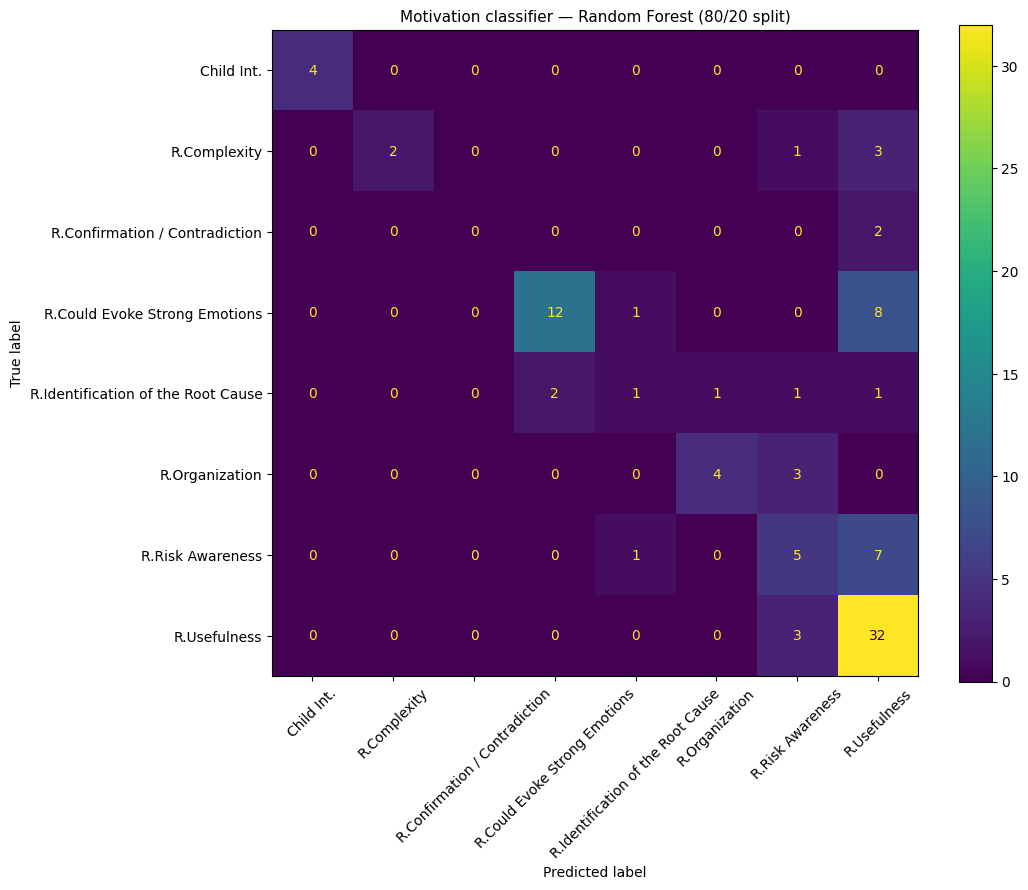

In [9]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X.values, y, test_size=0.2, random_state=RANDOM_STATE,
)

rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE)
rf.fit(X_tr, y_tr)
y_pred = rf.predict(X_te)

print(f'Test set F1 weighted: {f1_score(y_te, y_pred, average="weighted"):.3f}')
print(f'Test set F1 macro:    {f1_score(y_te, y_pred, average="macro"):.3f}')

short_labels = [c.replace('Response ', 'R.').replace('Child Intentions', 'Child Int.')
                for c in CLASSES]

fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred, display_labels=short_labels, ax=ax,
    xticks_rotation=45,
)
ax.set_title('Motivation classifier — Random Forest (80/20 split)', fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / 'motivation_confusion_matrix.png', dpi=100)
plt.show()

## Feature importance

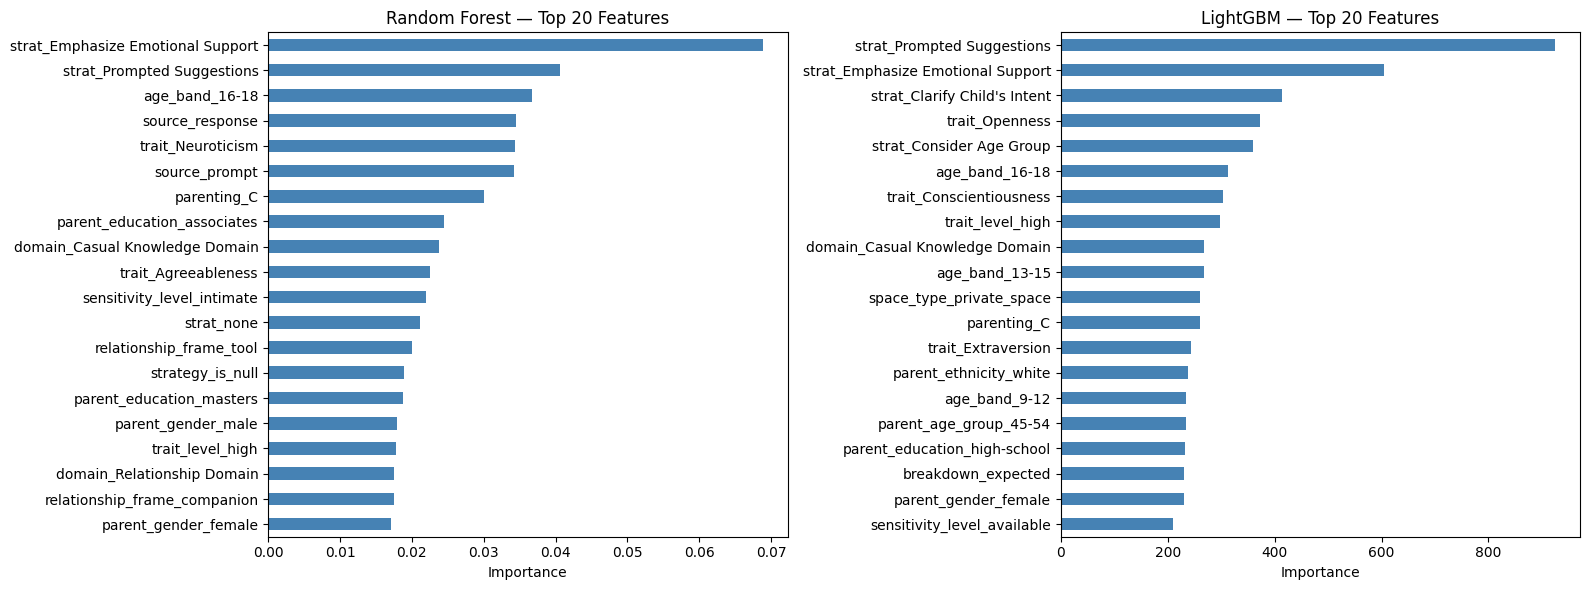

Top 10 RF features:
strat_Emphasize Emotional Support    0.068851
strat_Prompted Suggestions           0.040623
age_band_16-18                       0.036727
source_response                      0.034535
trait_Neuroticism                    0.034412
source_prompt                        0.034266
parenting_C                          0.030096
parent_education_associates          0.024533
domain_Casual Knowledge Domain       0.023732
trait_Agreeableness                  0.022515


In [10]:
rf_full = RandomForestClassifier(n_estimators=500, max_depth=8, random_state=RANDOM_STATE)
rf_full.fit(X.values, y)
rf_imp = pd.Series(rf_full.feature_importances_, index=X.columns).sort_values(ascending=False)

lgb_full = lgb.LGBMClassifier(n_estimators=200, max_depth=5, num_leaves=15,
                               verbose=-1, random_state=RANDOM_STATE)
lgb_full.fit(X.values, y)
lgb_imp = pd.Series(lgb_full.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, imp, title in [(axes[0], rf_imp, 'Random Forest'),
                       (axes[1], lgb_imp, 'LightGBM')]:
    imp.head(20).sort_values().plot.barh(ax=ax, color='steelblue')
    ax.set_title(f'{title} — Top 20 Features')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig(OUT_DIR / 'motivation_feature_importance.png', dpi=100)
plt.show()

print('Top 10 RF features:')
print(rf_imp.head(10).to_string())

## Logistic Regression coefficients per motivation class

With 8-class OVR, LR gives `coef_.shape = (8, n_features)`.  Positive coefficient = feature
pushes the prediction toward that class.

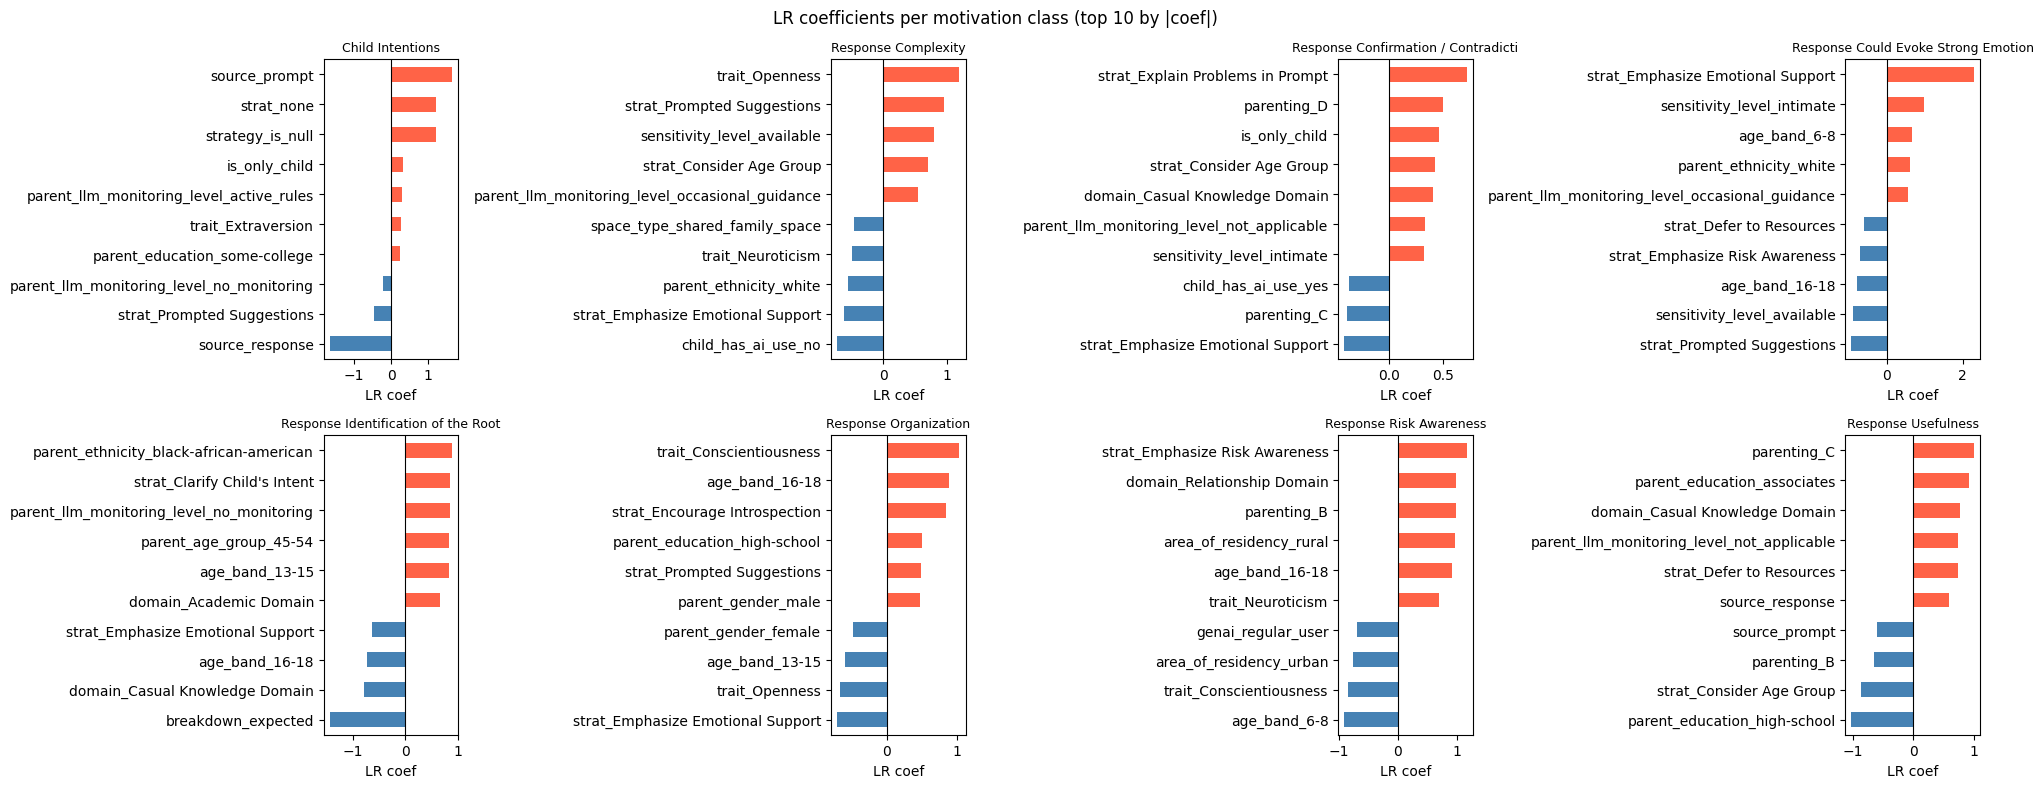

In [11]:
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
lr.fit(X.values, y)

n_cols = 4
n_rows = (N_CLASSES + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))

for cls_idx, (cls_name, ax) in enumerate(zip(CLASSES, axes.flat)):
    coef = pd.Series(lr.coef_[cls_idx], index=X.columns)
    top10 = coef.abs().nlargest(10).index
    coef[top10].sort_values().plot.barh(ax=ax, color=[
        'tomato' if v > 0 else 'steelblue' for v in coef[top10].sort_values()
    ])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(cls_name[:35], fontsize=9)
    ax.set_xlabel('LR coef')

for ax in axes.flat[N_CLASSES:]:
    ax.set_visible(False)

plt.suptitle('LR coefficients per motivation class (top 10 by |coef|)', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'motivation_lr_coefficients.png', dpi=100)
plt.show()

## Save class encoder for downstream notebooks

In [12]:
import json
(OUT_DIR / 'motivation_classes.json').write_text(
    json.dumps(list(CLASSES))
)
print('Saved motivation_classes.json')
print(CLASSES.tolist())

Saved motivation_classes.json
['Child Intentions', 'Response Complexity', 'Response Confirmation / Contradiction', 'Response Could Evoke Strong Emotions', 'Response Identification of the Root Cause', 'Response Organization', 'Response Risk Awareness', 'Response Usefulness']
